In [ ]:
import math
import random
import pandas as pd
import numpy as np, time
import matplotlib.pyplot as plt
import time
from mpl_toolkits.mplot3d import Axes3D

# ---- baseline parameters ----
base_params = {
    "lam": 0.27,
    "ph": 0.3,
    "pc": 0.9,
    "Etx": 1,
    "Bmax": 100
}

lam_grid = np.linspace(0.01, 0.80, 50)
ph_grid  = np.linspace(0.01, 0.50, 50)
pc_grid  = np.linspace(0.50, 1.00, 50)
Etx_grid = np.arange(1, 50)   # ints
Bmax_grid = np.array([1,2,5,10,50,100])

In [ ]:
def eop_stable(params):
    #eop = lambda/psv x Pr (B < Etx)
    #eop = lambda/(pc x Pr (B>=Etx)) x Pr (B < Etx)
    #eop = lambda x Etx/(pc x ph) x Pr (B < Etx)
    # r = pc x ph / lambda
    #eop = Etx / r  x (1-r^(Etx)/(1-r^(Bmax+1)))

    lam = float(params["lam"])
    ph = float(params["ph"])
    pc = float(params["pc"])
    Etx = int(params["Etx"])
    Bmax = int(params["Bmax"])
    r = pc*ph/lam
    if 0.98<r<1.02:
      eop = (lam / pc)  * Etx / (Bmax+1-Etx)
    else:
      eop = (lam / pc)  * (1-r**(Etx))/((1-r**(Bmax+1)))
    return eop


In [ ]:
def eop_saturated(params):
    lam = float(params["lam"])
    ph = float(params["ph"])
    pc = float(params["pc"])
    Etx = int(params["Etx"])
    Bmax = int(params["Bmax"])

    if (Etx>Bmax):
      return 1
    else:
      return (1 - ph/Etx)

In [ ]:
def compute_eop(params):
    lam = float(params["lam"])
    ph = float(params["ph"])
    pc = float(params["pc"])
    Etx = int(params["Etx"])
    Bmax = int(params["Bmax"])
    # Decide regime
    if lam <= (pc * ph / Etx):
        res = eop_stable(params)
        return {"regime": "stable", "eop": res}
    else:
        sat_res = eop_saturated(params)
        return {"regime": "saturated", "eop": sat_res}

In [ ]:
def simulate_eop(params, T=500_000, seed=12345, harvest_first=False):

    random.seed(seed)

    lam = float(params["lam"])
    ph  = float(params["ph"])
    pc  = float(params["pc"])
    Etx = int(params["Etx"])
    Bmax = int(params["Bmax"])

    # State variables
    Q = 0
    B = 0

    # Counters
    eop_slots = 0
    nonempty_slots = 0
    attempt_slots = 0
    successful_slots = 0

    for _ in range(T):

        if harvest_first:
            if random.random() < ph and B < Bmax:
                B += 1

        # ARRIVAL
        if random.random() < lam:
            Q += 1

        # MEASURE EOP BEFORE ATTEMPT
        if Q > 0:
            nonempty_slots += 1
            if B < Etx:
                eop_slots += 1

        # ATTEMPT transmission
        if Q > 0 and B >= Etx:
            attempt_slots += 1
            B -= Etx

            # success
            if random.random() < pc:
                successful_slots += 1
                Q -= 1
                if Q < 0:
                    Q = 0

        # HARVEST AT END if harvest_first=False
        if not harvest_first:
            if random.random() < ph and B < Bmax:
                B += 1

    # --- results ---
    eop_overall = eop_slots / T
    eop_given_Qpos = eop_slots / nonempty_slots if nonempty_slots > 0 else 0.0
    frac_Qpos = nonempty_slots / T
    attempt_frac = attempt_slots / T
    success_frac = successful_slots / T

    return {
        "params_used": params,
        "eop_overall": eop_overall,
        "eop_given_Qpos": eop_given_Qpos,
        "frac_Qpos": frac_Qpos,
        "attempt_frac": attempt_frac,
        "success_frac": success_frac,
        "eop_slots": eop_slots,
        "nonempty_slots": nonempty_slots,
        "T": T
    }

In [ ]:
# helper to extract eop from compute_eop result
def extract_eop_from_compute(res):
    if res is None:
        return float("nan")
    try:
        reg = res.get("regime", None)
        eop = res.get("eop", None)
        if eop is None:
            return float("nan")
        return float(eop)
    except Exception:
        return float("nan")

def compute_error_metrics(analytic, sim):
    mask = ~np.isnan(analytic) & ~np.isnan(sim)
    if mask.sum() == 0:
        return {"RMSE": np.nan, "MAE":np.nan, "MAX":np.nan, "PERC_lt_0.05":np.nan}
    ae = np.abs(analytic[mask] - sim[mask])
    return {"RMSE": float(np.sqrt(np.mean(ae**2))),
            "MAE": float(np.mean(ae)),
            "MAX": float(np.max(ae)),
            "PERC_lt_0.05": float(np.mean(ae < 0.05))}

def run_sweep_and_collect(key, values, filename_prefix, xlabel, base_params,
                          Tsim=20000, seed0=12345, harvest_first=True, verbose=True):
    """
    Sweep a single parameter 'key' over 'values'.
    Returns: (values_array, analytic_array, sim_array)
    Also saves npz if filename_prefix not None.
    """
    analytic_vals = []
    sim_vals = []
    n = len(values)
    t0 = time.time()
    for i, val in enumerate(values):
        params = base_params.copy()
        # set int params correctly
        if key in ("Etx", "Bmax"):
            params[key] = int(val)
        else:
            params[key] = float(val)

        # analytic
        try:
            ares = compute_eop(params)
            a_eop = extract_eop_from_compute(ares)
        except Exception as e:
            if verbose:
                print(f"[analytic error] {key}={val}: {e}")
            a_eop = float("nan")
        analytic_vals.append(a_eop)

        # simulate
        try:
            seed = seed0 + i * 42
            sres = simulate_eop(params, T=Tsim, seed=seed, harvest_first=harvest_first)
            s_eop = float(sres["eop_overall"])
        except Exception as e:
            if verbose:
                print(f"[sim error] {key}={val}: {e}")
            s_eop = float("nan")
        sim_vals.append(s_eop)

        if verbose and (i % max(1, n//5) == 0):
            elapsed = time.time() - t0
            print(f"[{filename_prefix}] {i+1}/{n} done, {key}={val:.4g}, elapsed={elapsed:.1f}s")

    values_arr = np.array(values)
    analytic_arr = np.array(analytic_vals, dtype=float)
    sim_arr = np.array(sim_vals, dtype=float)

    # save results for later plotting/inspection
    if filename_prefix:
        fname = f"{filename_prefix}.npz"
        np.savez(fname, values=values_arr, analytic=analytic_arr, sim=sim_arr)
        if verbose:
            print(f"Saved {fname}")

    return values_arr, analytic_arr, sim_arr


In [ ]:
sweeps = {
    "lam": lam_grid,
    "ph": ph_grid,
    "pc": pc_grid,
    "Etx": Etx_grid
}

Tsim = 50000
seed0 = 42
harvest_first = True

results_1d = {}
metrics_rows = []

for key, grid in sweeps.items():
    print(f"\nRunning 1D sweep for {key} ...")

    # run the sweep for THIS key using the general function
    vals, analytic_vals, sim_vals = run_sweep_and_collect(
        key, grid,
        filename_prefix=f"sweep_{key}",
        xlabel=key,
        base_params=base_params,
        Tsim=Tsim,
        seed0=seed0,
        harvest_first=harvest_first
    )

    # save arrays explicitly
    np.savez(f"sweep_{key}.npz",
             values=vals,
             analytic=analytic_vals,
             sim=sim_vals)

    # compute error metrics for THIS parameter
    m = compute_error_metrics(analytic_vals, sim_vals)
    metrics_rows.append({"param": key, **m})

    # store full results for later use
    results_1d[key] = (vals, analytic_vals, sim_vals)

# Final 1D table
metrics_df = pd.DataFrame(metrics_rows)
metrics_df



Running 1D sweep for lam ...
[sweep_lam] 1/50 done, lam=0.01, elapsed=0.0s
[sweep_lam] 11/50 done, lam=0.1712, elapsed=0.1s
[sweep_lam] 21/50 done, lam=0.3324, elapsed=0.4s
[sweep_lam] 31/50 done, lam=0.4937, elapsed=0.7s
[sweep_lam] 41/50 done, lam=0.6549, elapsed=1.0s
Saved sweep_lam.npz

Running 1D sweep for ph ...
[sweep_ph] 1/50 done, ph=0.01, elapsed=0.0s
[sweep_ph] 11/50 done, ph=0.11, elapsed=0.3s
[sweep_ph] 21/50 done, ph=0.21, elapsed=0.5s
[sweep_ph] 31/50 done, ph=0.31, elapsed=0.8s
[sweep_ph] 41/50 done, ph=0.41, elapsed=1.0s
Saved sweep_ph.npz

Running 1D sweep for pc ...
[sweep_pc] 1/50 done, pc=0.5, elapsed=0.0s
[sweep_pc] 11/50 done, pc=0.602, elapsed=0.3s
[sweep_pc] 21/50 done, pc=0.7041, elapsed=0.4s
[sweep_pc] 31/50 done, pc=0.8061, elapsed=0.6s
[sweep_pc] 41/50 done, pc=0.9082, elapsed=0.7s
Saved sweep_pc.npz

Running 1D sweep for Etx ...
[sweep_Etx] 1/49 done, Etx=1, elapsed=0.0s
[sweep_Etx] 10/49 done, Etx=10, elapsed=0.1s
[sweep_Etx] 19/49 done, Etx=19, elapsed=

,param,RMSE,MAE,MAX,PERC_lt_0.05
0,lam,0.094338,0.014852,0.666863,0.980000
1,ph,0.059094,0.010496,0.414200,0.960000
2,pc,0.097918,0.025271,0.526860,0.940000
3,Etx,0.076826,0.011103,0.537780,0.979592


Saved combined 1D sweeps figure to figure_1D_sweeps_row.png


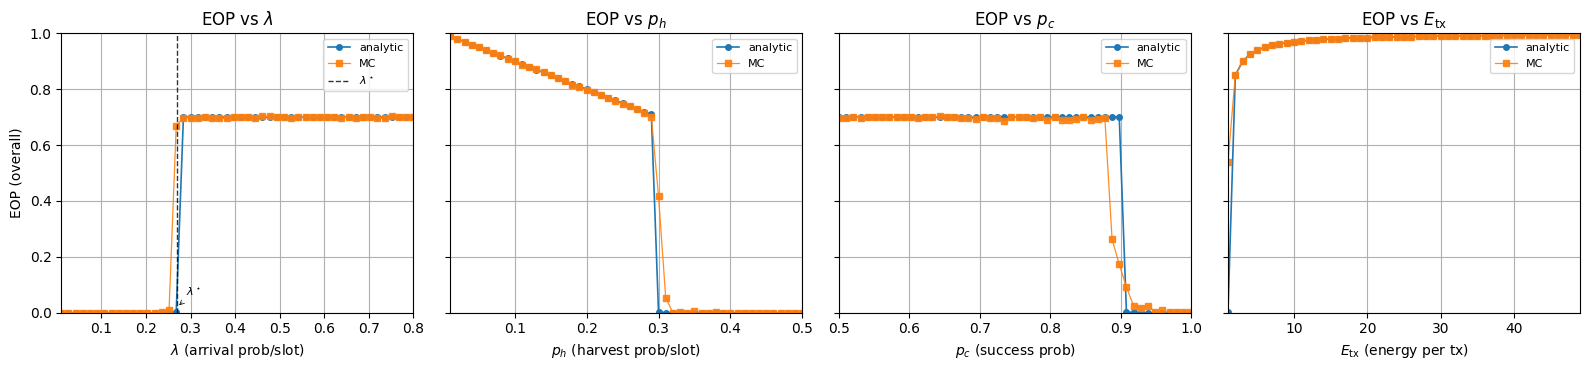

Saved individual sweep figure to figure_1D_sweep_a.png


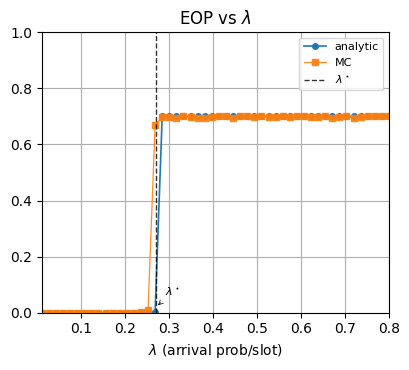

Saved individual sweep figure to figure_1D_sweep_b.png


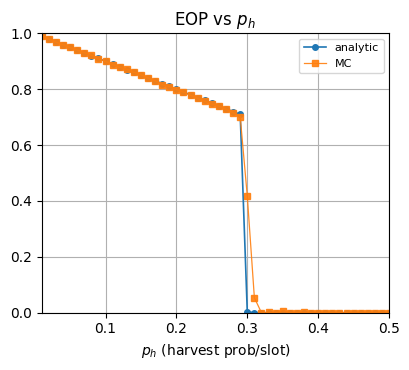

Saved individual sweep figure to figure_1D_sweep_c.png


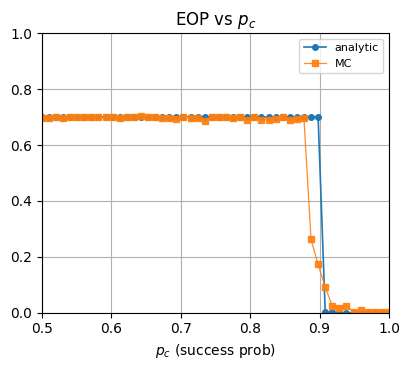

Saved individual sweep figure to figure_1D_sweep_d.png


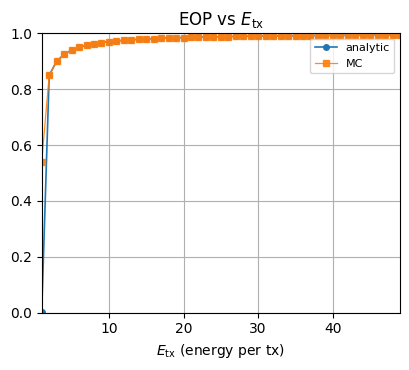

In [ ]:
import string

sweep_files = [
    ("sweep_lam.npz", r"$\lambda$", r"$\lambda$ (arrival prob/slot)"),
    ("sweep_ph.npz",  r"$p_h$",  r"$p_h$ (harvest prob/slot)"),
    ("sweep_pc.npz",  r"$p_c$",  r"$p_c$ (success prob)"),
    ("sweep_Etx.npz", r"$E_{\mathrm{tx}}$", r"$E_{\mathrm{tx}}$ (energy per tx)")
]

bp = base_params.copy()
pc0 = float(bp.get("pc", 0.9))
ph0 = float(bp.get("ph", 0.3))
Etx0 = int(bp.get("Etx", 1))
lambda_star = pc0 * ph0 / Etx0

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, (fname, key, xlabel) in zip(axes, sweep_files):
    try:
        data = np.load(fname, allow_pickle=True)
    except Exception as e:
        ax.text(0.5, 0.5, f"File not found\n{fname}", ha='center', va='center', fontsize=10)
        ax.set_title(key)
        continue

    vals = data['values'] if 'values' in data else data.get('grid', data.get('grid_x', None))
    analytic = data['analytic'] if 'analytic' in data else data.get('avals', data.get('analytic_vals', None))
    sim = data['sim'] if 'sim' in data else data.get('svals', data.get('sim_vals', None))

    vals = np.array(vals)
    analytic = np.array(analytic, dtype=float) if analytic is not None else np.full_like(vals, np.nan, dtype=float)
    sim = np.array(sim, dtype=float) if sim is not None else np.full_like(vals, np.nan, dtype=float)

    ax.plot(vals, analytic, '-o', label='analytic', markersize=4, linewidth=1.2)
    ax.plot(vals, sim, '-s', label='MC', markersize=4, linewidth=0.9, alpha=0.9)
    ax.set_xlabel(xlabel)
    if key == r"$\lambda$":
        ax.axvline(lambda_star, color='k', linestyle='--', linewidth=1.0, alpha=0.8, label=r'$\lambda^\star$')
        ax.annotate(r'$\lambda^\star$', xy=(lambda_star, 0.02), xytext=(lambda_star+0.02, 0.06),
                    fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.5), color='k')
    ax.grid(True)
    ax.set_xlim(vals.min(), vals.max())
    ax.set_ylim(0.0, 1.0)
    ax.set_title(f"EOP vs {key}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("EOP (overall)")
plt.tight_layout()

out_png = "figure_1D_sweeps_row.png"
plt.savefig(out_png, dpi=300)
print(f"Saved combined 1D sweeps figure to {out_png}")
plt.show()
plt.close(fig)

letters = list(string.ascii_lowercase)
for i, (fname, key, xlabel) in enumerate(sweep_files):
    letter = letters[i]  # 'a','b','c','d', ...
    try:
        data = np.load(fname, allow_pickle=True)
    except Exception as e:
        print(f"Skipping {fname}: file not found ({e})")
        continue

    vals = data['values'] if 'values' in data else data.get('grid', data.get('grid_x', None))
    analytic = data['analytic'] if 'analytic' in data else data.get('avals', data.get('analytic_vals', None))
    sim = data['sim'] if 'sim' in data else data.get('svals', data.get('sim_vals', None))

    vals = np.array(vals)
    analytic = np.array(analytic, dtype=float) if analytic is not None else np.full_like(vals, np.nan, dtype=float)
    sim = np.array(sim, dtype=float) if sim is not None else np.full_like(vals, np.nan, dtype=float)

    fig_i, ax_i = plt.subplots(1, 1, figsize=(4.2, 3.8))
    ax_i.plot(vals, analytic, '-o', label='analytic', markersize=4, linewidth=1.2)
    ax_i.plot(vals, sim, '-s', label='MC', markersize=4, linewidth=0.9, alpha=0.9)
    ax_i.set_xlabel(xlabel)
    if key == r"$\lambda$":
        ax_i.axvline(lambda_star, color='k', linestyle='--', linewidth=1.0, alpha=0.8, label=r'$\lambda^\star$')
        ax_i.annotate(r'$\lambda^\star$', xy=(lambda_star, 0.02), xytext=(lambda_star+0.02, 0.06),
                      fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.5), color='k')
    ax_i.grid(True)
    ax_i.set_xlim(vals.min(), vals.max())
    ax_i.set_ylim(0.0, 1.0)
    ax_i.set_title(f"EOP vs {key}")
    ax_i.legend(fontsize=8)

    plt.tight_layout()
    out_single = f"figure_1D_sweep_{letter}.png"
    plt.savefig(out_single, dpi=300)
    print(f"Saved individual sweep figure to {out_single}")
    plt.show()
    plt.close(fig_i)

In [ ]:
def run_2d_sweep(param_x, grid_x, param_y, grid_y, base_params,
                 Tsim=20000, seed0=42, harvest_first=True, verbose=True):
    nx = len(grid_x); ny = len(grid_y)
    analytic = np.full((ny, nx), np.nan, dtype=float)
    sim = np.full((ny, nx), np.nan, dtype=float)
    t0 = time.time()
    total = nx * ny
    k = 0
    for i, yval in enumerate(grid_y):
        for j, xval in enumerate(grid_x):
            k += 1
            params = base_params.copy()
            # assign correctly
            params[param_x] = int(xval) if param_x in ("Etx","Bmax") else float(xval)
            params[param_y] = int(yval) if param_y in ("Etx","Bmax") else float(yval)

            # analytic
            try:
                ares = compute_eop(params)
                a_eop = extract_eop_from_compute(ares)
            except Exception as e:
                if verbose: print(f"[analytic err] {param_x}={xval}, {param_y}={yval}: {e}")
                a_eop = float("nan")
            analytic[i, j] = a_eop

            # simulate
            try:
                seed = seed0 + i*1000 + j*17
                sres = simulate_eop(params, T=Tsim, seed=seed, harvest_first=harvest_first)
                s_eop = float(sres["eop_overall"])
            except Exception as e:
                if verbose: print(f"[sim err] {param_x}={xval}, {param_y}={yval}: {e}")
                s_eop = float("nan")
            sim[i, j] = s_eop

            if verbose and (k % max(1, total//10) == 0):
                elapsed = time.time() - t0
                print(f"[{param_x}-{param_y}] {k}/{total} done (x={xval}, y={yval}), elapsed={elapsed:.1f}s")

    return analytic, sim


In [ ]:
def plot_error_heatmap(grid_x, grid_y, analytic, sim,
                       param_x, param_y, prefix="error"):

    err = np.abs(analytic - sim)
    vmin = np.nanmin(err)
    vmax = np.nanmax(err)

    plt.figure(figsize=(7,5))
    plt.imshow(err,
               origin="lower",
               aspect="auto",
               extent=(grid_x[0], grid_x[-1], grid_y[0], grid_y[-1]),
               cmap="viridis",
               vmin=vmin, vmax=vmax)

    plt.colorbar(label="Absolute error (EOP)")
    plt.xlabel(param_x)
    plt.ylabel(param_y)
    plt.title(f"Absolute error |analytic - MC|: {param_x} vs {param_y}")

    fname = f"{prefix}_heatmap_{param_x}_{param_y}.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    print(f"Saved heatmap: {fname}")

    plt.show()


[lam-ph] 250/2500 done (x=0.8, y=0.05), elapsed=3.3s
[lam-ph] 500/2500 done (x=0.8, y=0.09999999999999999), elapsed=7.7s
[lam-ph] 750/2500 done (x=0.8, y=0.15000000000000002), elapsed=11.1s
[lam-ph] 1000/2500 done (x=0.8, y=0.2), elapsed=14.5s
[lam-ph] 1250/2500 done (x=0.8, y=0.25), elapsed=18.2s
[lam-ph] 1500/2500 done (x=0.8, y=0.3), elapsed=22.6s
[lam-ph] 1750/2500 done (x=0.8, y=0.35000000000000003), elapsed=26.1s
[lam-ph] 2000/2500 done (x=0.8, y=0.4), elapsed=29.7s
[lam-ph] 2250/2500 done (x=0.8, y=0.45), elapsed=34.4s
[lam-ph] 2500/2500 done (x=0.8, y=0.5), elapsed=38.0s
Saved heatmap: error_heatmap_$\lambda$_$p_h$.png


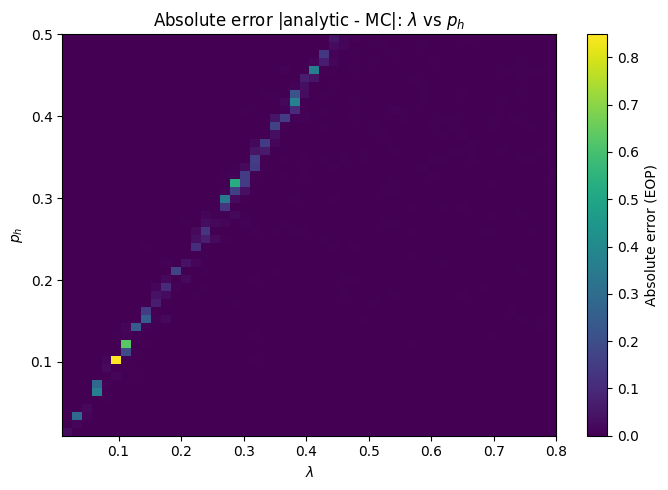

[lam-pc] 250/2500 done (x=0.8, y=0.5408163265306123), elapsed=3.5s
[lam-pc] 500/2500 done (x=0.8, y=0.5918367346938775), elapsed=8.3s
[lam-pc] 750/2500 done (x=0.8, y=0.6428571428571428), elapsed=12.0s
[lam-pc] 1000/2500 done (x=0.8, y=0.6938775510204082), elapsed=15.6s
[lam-pc] 1250/2500 done (x=0.8, y=0.7448979591836735), elapsed=20.3s
[lam-pc] 1500/2500 done (x=0.8, y=0.7959183673469388), elapsed=23.9s
[lam-pc] 1750/2500 done (x=0.8, y=0.846938775510204), elapsed=27.5s
[lam-pc] 2000/2500 done (x=0.8, y=0.8979591836734693), elapsed=32.1s
[lam-pc] 2250/2500 done (x=0.8, y=0.9489795918367346), elapsed=35.7s
[lam-pc] 2500/2500 done (x=0.8, y=1.0), elapsed=39.2s
Saved heatmap: error_heatmap_$\lambda$_$p_c$.png


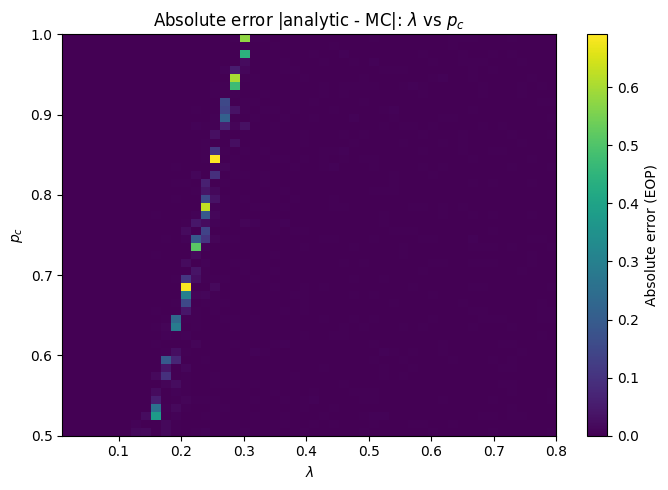

[lam-Etx] 245/2450 done (x=0.7193877551020408, y=5), elapsed=4.0s
[lam-Etx] 490/2450 done (x=0.6387755102040816, y=10), elapsed=7.7s
[lam-Etx] 735/2450 done (x=0.5581632653061224, y=15), elapsed=10.9s
[lam-Etx] 980/2450 done (x=0.4775510204081632, y=20), elapsed=14.2s
[lam-Etx] 1225/2450 done (x=0.39693877551020407, y=25), elapsed=18.6s
[lam-Etx] 1470/2450 done (x=0.3163265306122449, y=30), elapsed=21.8s
[lam-Etx] 1715/2450 done (x=0.2357142857142857, y=35), elapsed=25.0s
[lam-Etx] 1960/2450 done (x=0.15510204081632653, y=40), elapsed=28.6s
[lam-Etx] 2205/2450 done (x=0.07448979591836734, y=45), elapsed=32.6s
[lam-Etx] 2450/2450 done (x=0.8, y=49), elapsed=35.7s
Saved heatmap: error_heatmap_$\lambda$_$E_{\mathrm{tx}}$.png


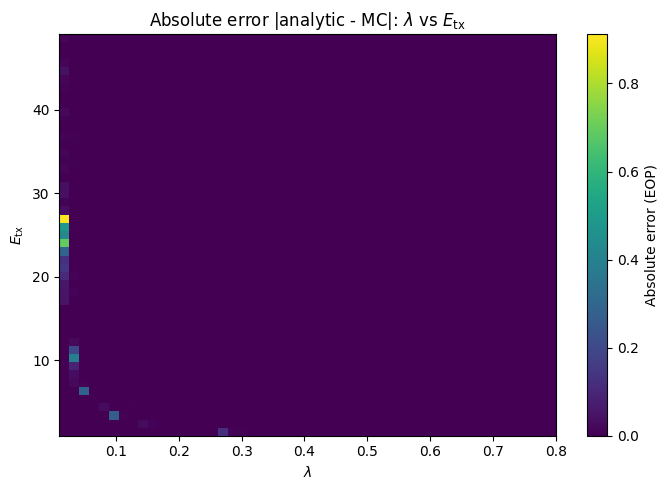

In [ ]:
latex_labels = {
    "lam": r"$\lambda$",
    "ph":  r"$p_h$",
    "pc":  r"$p_c$",
    "Etx": r"$E_{\mathrm{tx}}$"
}

pairs = [
    ("lam", lam_grid, "ph",  ph_grid),
    ("lam", lam_grid, "pc",  pc_grid),
    ("lam", lam_grid, "Etx", Etx_grid)
]

for px, gx, py, gy in pairs:
    a_mat, s_mat = run_2d_sweep(
        px, gx, py, gy,
        base_params,
        Tsim=Tsim, seed0=seed0, harvest_first=harvest_first
    )

    np.savez(f"grid_{px}_{py}.npz",
             grid_x=gx, grid_y=gy, analytic=a_mat, sim=s_mat)
    plot_error_heatmap(
        gx, gy,
        a_mat, s_mat,
        latex_labels[px], latex_labels[py],
        prefix="error"
    )


In [ ]:
def plot_3d_surface(grid_x, grid_y, analytic, sim,
                    param_x='x', param_y='y', prefix="surface"):
    """
    Plot analytic and simulation EOP as two 3D surfaces side-by-side.
    grid_x: 1D array for x-axis (length nx)
    grid_y: 1D array for y-axis (length ny)
    analytic, sim: shape (ny, nx) arrays
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import numpy as np

    X, Y = np.meshgrid(np.array(grid_x), np.array(grid_y))

    fig = plt.figure(figsize=(12,5))

    # Analytic surface
    ax1 = fig.add_subplot(121, projection="3d")
    surf1 = ax1.plot_surface(X, Y, np.array(analytic),
                             cmap="coolwarm", linewidth=0, antialiased=False)
    ax1.set_xlabel(param_x)
    ax1.set_ylabel(param_y)
    ax1.set_zlabel("EOP")
    ax1.set_title("Analytic EOP")
    fig.colorbar(surf1, ax=ax1, shrink=0.6)

    # Simulation surface
    ax2 = fig.add_subplot(122, projection="3d")
    surf2 = ax2.plot_surface(X, Y, np.array(sim),
                             cmap="coolwarm", linewidth=0, antialiased=False)
    ax2.set_xlabel(param_x)
    ax2.set_ylabel(param_y)
    ax2.set_zlabel("EOP")
    ax2.set_title("Monte Carlo EOP")
    fig.colorbar(surf2, ax=ax2, shrink=0.6)

    plt.tight_layout()
    fname = f"{prefix}_3d_{param_x}_{param_y}.png"
    try:
        plt.savefig(fname, dpi=200)
        print(f"Saved 3D surface to {fname}")
    except Exception as e:
        print("Warning: could not save figure:", e)
    plt.show()


Saved 3D surface to surface_3d_lam_ph.png


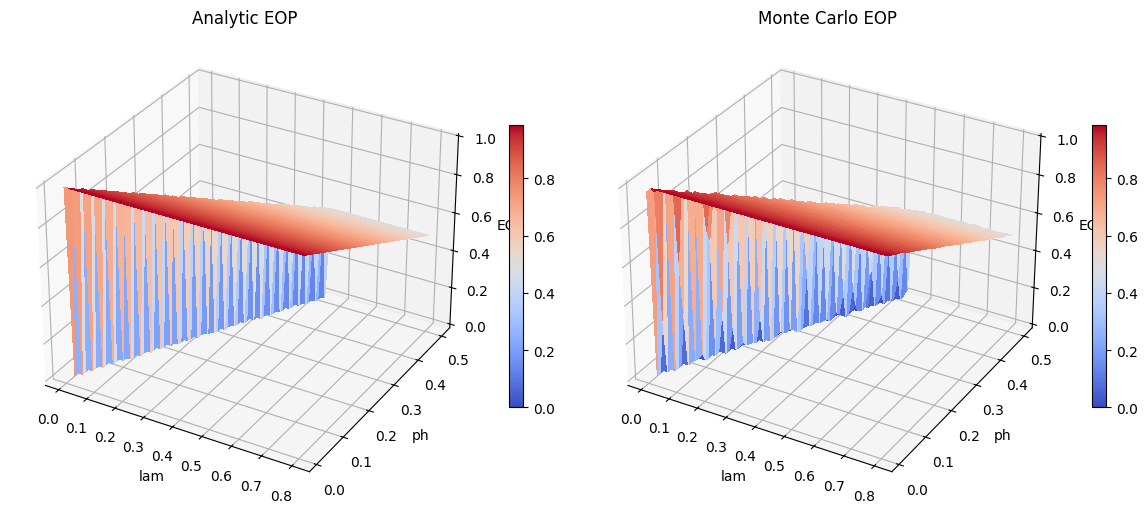

In [ ]:
# Load a_mat, s_mat from file or compute with coarser grids
a = np.load("grid_lam_ph.npz")
plot_3d_surface(a['grid_x'], a['grid_y'], a['analytic'], a['sim'], 'lam', 'ph', prefix="surface")


In [ ]:
Bvals = [1, 2, 5, 20, 100]
b_results = []

for B in Bvals:
    print(f"\nRunning Bmax test for Bmax={B} ...")
    params_B = base_params.copy()
    params_B['Bmax'] = int(B)

    # run sweep over lambda
    vals, analytic_vals, sim_vals = run_sweep_and_collect(
        key="lam",
        values=lam_grid,
        filename_prefix=f"sweep_lam_B{B}",
        xlabel=r"$\lambda$ (arrival prob/slot)",
        base_params=params_B,
        Tsim=Tsim,
        seed0=seed0,
        harvest_first=harvest_first,
        verbose=True
    )

    m = compute_error_metrics(np.array(analytic_vals), np.array(sim_vals))
    m['Bmax'] = B
    b_results.append(m)

import pandas as pd
b_results_df = pd.DataFrame(b_results)
b_results_df




Running Bmax test for Bmax=1 ...
[sweep_lam_B1] 1/50 done, lam=0.01, elapsed=0.0s
[sweep_lam_B1] 11/50 done, lam=0.1712, elapsed=0.1s
[sweep_lam_B1] 21/50 done, lam=0.3324, elapsed=0.3s
[sweep_lam_B1] 31/50 done, lam=0.4937, elapsed=0.4s
[sweep_lam_B1] 41/50 done, lam=0.6549, elapsed=0.6s
Saved sweep_lam_B1.npz

Running Bmax test for Bmax=2 ...
[sweep_lam_B2] 1/50 done, lam=0.01, elapsed=0.0s
[sweep_lam_B2] 11/50 done, lam=0.1712, elapsed=0.2s
[sweep_lam_B2] 21/50 done, lam=0.3324, elapsed=0.4s
[sweep_lam_B2] 31/50 done, lam=0.4937, elapsed=0.7s
[sweep_lam_B2] 41/50 done, lam=0.6549, elapsed=1.0s
Saved sweep_lam_B2.npz

Running Bmax test for Bmax=5 ...
[sweep_lam_B5] 1/50 done, lam=0.01, elapsed=0.0s
[sweep_lam_B5] 11/50 done, lam=0.1712, elapsed=0.2s
[sweep_lam_B5] 21/50 done, lam=0.3324, elapsed=0.4s
[sweep_lam_B5] 31/50 done, lam=0.4937, elapsed=0.7s
[sweep_lam_B5] 41/50 done, lam=0.6549, elapsed=1.0s
Saved sweep_lam_B5.npz

Running Bmax test for Bmax=20 ...
[sweep_lam_B20] 1/50 do

,RMSE,MAE,MAX,PERC_lt_0.05,Bmax
0,0.143472,0.065885,0.489080,0.76,1
1,0.136669,0.054155,0.546174,0.80,2
2,0.112779,0.034065,0.609054,0.90,5
3,0.088190,0.016817,0.604853,0.96,20
4,0.094338,0.014852,0.666863,0.98,100
